# DPO(Direct Preference Optimization) 미세조정 실습

이 노트에서는 선호 데이터의 `chosen` 응답과 `rejected` 응답을 이용해 GPT-2를 DPO 방식으로 미세조정한다.


## 학습 목표

- preference dataset의 `prompt`, `chosen`, `rejected` 구조를 이해한다.
- LoRA를 이용해 적은 GPU 메모리로 DPO 미세조정을 수행한다.
- `DPOConfig`와 최신 `DPOTrainer`를 설정한다.
- DPO loss가 chosen의 상대 확률은 높이고 rejected의 상대 확률은 낮추는 원리를 이해한다.
- base GPT-2와 DPO 모델의 생성을 비교한다.

## 1. 환경 설정

### 1.1 라이브러리 설치


In [1]:
%%time

!pip uninstall -y torchao

%pip install -q -U \
  "trl==1.9.0" \
  "transformers==5.14.1" \
  "peft==0.19.1" \
  "datasets==5.0.0" \
  "accelerate==1.14.0" \
  "matplotlib==3.11.1" \
  "pandas"

Found existing installation: torchao 0.10.0
Uninstalling torchao-0.10.0:
  Successfully uninstalled torchao-0.10.0
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 2.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 885.0/885.0 kB 26.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 76.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 28.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 84.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 67.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 12.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.5 whi

### 1.2 GPU 및 패키지 버전 확인

In [2]:
import importlib.metadata as metadata
import torch

print("PyTorch:", torch.__version__)
print("CUDA 사용 가능:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("GPU가 잡히지 않았다. Colab 메뉴에서 런타임 > 런타임 유형 변경 > T4 GPU 등을 선택한다.")

for package in ["trl", "transformers", "peft", "datasets", "accelerate"]:
    print(f"{package}: {metadata.version(package)}")

PyTorch: 2.11.0+cu128
CUDA 사용 가능: True
GPU: Tesla T4
trl: 1.9.0
transformers: 5.14.1
peft: 0.19.1
datasets: 5.0.0
accelerate: 1.14.0


### 1.3 라이브러리 import

In [3]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import torch
from datasets import load_dataset
from peft import AutoPeftModelForCausalLM, LoraConfig
from transformers import AutoModelForCausalLM, AutoTokenizer, GenerationConfig, set_seed
from trl import DPOConfig, DPOTrainer

set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("사용 device:", device)

사용 device: cuda


## 2. 모델과 토크나이저 준비

원본 실습과 동일하게 GPT-2를 사용한다. DPO 학습에서는 현재 policy와 reference policy의 log-probability 차이를 비교한다.

LoRA를 사용할 경우 최신 `DPOTrainer`가 adapter를 비활성화한 상태를 reference로 활용할 수 있으므로 별도의 `ref_model`을 반드시 만들 필요는 없다.

In [4]:
MODEL_NAME = "gpt2"

model = AutoModelForCausalLM.from_pretrained(MODEL_NAME)
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
model.config.pad_token_id = tokenizer.pad_token_id

print("모델:", MODEL_NAME)
print("pad token:", tokenizer.pad_token)

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  548MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

모델: gpt2
pad token: <|endoftext|>


## 3. Preference 데이터셋 전처리

`BarraHome/ultrafeedback_binarized` 데이터셋에는 하나의 prompt에 대해 더 선호되는 `chosen` 응답과 덜 선호되는 `rejected` 응답이 들어 있다.

DPOTrainer에 필요한 핵심 형식은 다음과 같다.

| 필드 | 의미 |
|---|---|
| `prompt` | 모델에 주는 입력 |
| `chosen` | 선호되는 응답 |
| `rejected` | 선호되지 않는 응답 |

In [5]:
ds = load_dataset("BarraHome/ultrafeedback_binarized")
print(ds)
print("split:", ds.keys())

README.md:   0%|          | 0.00/1.41k [00:00<?, ?B/s]

data/train_prefs-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  226MB            

data/train_prefs-00000-of-00001.parquet: downloading bytes:           |  0.00B            

data/test_prefs-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 7.29MB            

data/test_prefs-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

Generating test_prefs split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test_sft split:   0%|          | 0/1000 [00:00<?, ? examples/s]

Generating train_gen split:   0%|          | 0/61135 [00:00<?, ? examples/s]

Generating test_gen split:   0%|          | 0/1000 [00:00<?, ? examples/s]

DatasetDict({
    train_prefs: Dataset({
        features: ['prompt', 'prompt_id', 'chosen', 'rejected', 'messages', 'score_chosen', 'score_rejected'],
        num_rows: 61135
    })
    train_sft: Dataset({
        features: ['prompt', 'prompt_id', 'chosen', 'rejected', 'messages', 'score_chosen', 'score_rejected'],
        num_rows: 61135
    })
    test_prefs: Dataset({
        features: ['prompt', 'prompt_id', 'chosen', 'rejected', 'messages', 'score_chosen', 'score_rejected'],
        num_rows: 2000
    })
    test_sft: Dataset({
        features: ['prompt', 'prompt_id', 'chosen', 'rejected', 'messages', 'score_chosen', 'score_rejected'],
        num_rows: 1000
    })
    train_gen: Dataset({
        features: ['prompt', 'prompt_id', 'chosen', 'rejected', 'messages', 'score_chosen', 'score_rejected'],
        num_rows: 61135
    })
    test_gen: Dataset({
        features: ['prompt', 'prompt_id', 'chosen', 'rejected', 'messages', 'score_chosen', 'score_rejected'],
        num_rows

### 3.1 원본 샘플 구조 확인

In [6]:
print(ds["train_prefs"][0].keys())
ds["train_prefs"][0]

dict_keys(['prompt', 'prompt_id', 'chosen', 'rejected', 'messages', 'score_chosen', 'score_rejected'])


{'prompt': 'how can i develop a habit of drawing daily',
 'prompt_id': '086b3e24f29b8956a01059f79c56db35d118a06fb6b844b095737d042795cd43',
 'chosen': [{'content': 'how can i develop a habit of drawing daily',
   'role': 'user'},
  {'content': "Developing a daily habit of drawing can be challenging but with consistent practice and a few tips, it can become an enjoyable and rewarding part of your daily routine. Here are some strategies to help you develop the habit of drawing daily:\n\n1. Set a specific time: Allocate a specific time of the day to draw. It could be in the morning, afternoon, or evening. Make drawing a part of your daily routine.\n2. Set a specific duration: Determine the amount of time you want to spend on drawing each day. It can be as little as 10 minutes or as long as an hour. Be consistent with the duration to help build the habit.\n3. Start small and simple: Don't try to create a masterpiece every day, start with simple and easy-to-do sketches. Focus on improving yo

### 3.2 DPOTrainer 입력 형식으로 변환

원본 데이터의 `chosen`과 `rejected`는 대화 메시지 리스트 형태다. 마지막 assistant 메시지의 내용을 문자열로 꺼내 사용한다.

Colab 실습 시간을 고려해 train/eval 각각 최대 50개만 사용한다.

In [7]:
def extract_message_content(value):
    """대화 메시지 리스트 또는 문자열에서 실제 응답 문자열을 꺼낸다."""
    if isinstance(value, str):
        return value
    if isinstance(value, list) and len(value) > 0:
        last = value[-1]
        if isinstance(last, dict) and "content" in last:
            return last["content"]
    return str(value)


def process_row(row):
    return {
        "prompt": row["prompt"],
        "chosen": extract_message_content(row["chosen"]),
        "rejected": extract_message_content(row["rejected"]),
    }

TRAIN_SPLIT = "train_prefs"
EVAL_SPLIT = "test_prefs" if "test_prefs" in ds else TRAIN_SPLIT

train_count = min(50, len(ds[TRAIN_SPLIT]))
eval_count = min(50, len(ds[EVAL_SPLIT]))

train_dataset = ds[TRAIN_SPLIT].select(range(train_count)).map(
    process_row,
    remove_columns=ds[TRAIN_SPLIT].column_names,
)
eval_dataset = ds[EVAL_SPLIT].select(range(eval_count)).map(
    process_row,
    remove_columns=ds[EVAL_SPLIT].column_names,
)

print(train_dataset)
train_dataset[0]

Map:   0%|          | 0/50 [00:00<?, ? examples/s]

Map:   0%|          | 0/50 [00:00<?, ? examples/s]

Dataset({
    features: ['prompt', 'chosen', 'rejected'],
    num_rows: 50
})


{'prompt': 'how can i develop a habit of drawing daily',
 'chosen': "Developing a daily habit of drawing can be challenging but with consistent practice and a few tips, it can become an enjoyable and rewarding part of your daily routine. Here are some strategies to help you develop the habit of drawing daily:\n\n1. Set a specific time: Allocate a specific time of the day to draw. It could be in the morning, afternoon, or evening. Make drawing a part of your daily routine.\n2. Set a specific duration: Determine the amount of time you want to spend on drawing each day. It can be as little as 10 minutes or as long as an hour. Be consistent with the duration to help build the habit.\n3. Start small and simple: Don't try to create a masterpiece every day, start with simple and easy-to-do sketches. Focus on improving your skills gradually.\n4. Use a variety of tools and mediums: Experiment with different tools like pencils, pens, markers, and different mediums like paper, canvas, or digital 

## 4. LoRA 설정

GPT-2의 attention projection에 LoRA adapter를 붙인다. 전체 파라미터를 업데이트하는 대신 작은 low-rank 행렬만 학습하므로 Colab GPU 메모리를 줄일 수 있다.

GPT-2의 `Conv1D` 계열 projection은 일반적인 Linear layer와 weight 저장 방향이 달라 `fan_in_fan_out=True`를 사용한다.

In [8]:
peft_config = LoraConfig(
    r=4,
    lora_alpha=8,
    lora_dropout=0.1,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=["c_attn", "c_proj"],
    fan_in_fan_out=True,
)

peft_config

LoraConfig(task_type='CAUSAL_LM', peft_type=<PeftType.LORA: 'LORA'>, auto_mapping=None, peft_version='0.19.1', base_model_name_or_path=None, revision=None, inference_mode=False, r=4, target_modules={'c_attn', 'c_proj'}, exclude_modules=None, lora_alpha=8, lora_dropout=0.1, fan_in_fan_out=True, bias='none', use_rslora=False, modules_to_save=None, init_lora_weights=True, layers_to_transform=None, layers_pattern=None, rank_pattern={}, alpha_pattern={}, megatron_config=None, megatron_core='megatron.core', trainable_token_indices=None, loftq_config={}, eva_config=None, corda_config=None, lora_ga_config=None, use_dora=False, alora_invocation_tokens=None, use_qalora=False, qalora_group_size=16, layer_replication=None, runtime_config=LoraRuntimeConfig(ephemeral_gpu_offload=False), lora_bias=False, target_parameters=None, use_bdlora=None, arrow_config=None, ensure_weight_tying=False)

## 5. DPO 설정

DPO는 별도의 reward model이나 PPO rollout 없이 preference pair를 직접 사용한다.

핵심적으로는 chosen이 rejected보다 더 높은 상대적 log-probability를 갖도록 policy를 학습한다. 이때 reference model과 비교한 변화량을 사용하기 때문에 무작정 chosen 확률만 키우는 것과는 다르다.

`beta`는 reference policy에서 얼마나 벗어날지 조절하는 정도와 관련된다.

In [9]:
training_args = DPOConfig(
    output_dir="./dpo_output",
    beta=0.1,
    num_train_epochs=5,
    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=4,
    learning_rate=1e-4,
    warmup_steps=2,
    max_length=512,
    logging_steps=5,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=2,
    gradient_checkpointing=False,
    fp16=torch.cuda.is_available(),
    bf16=False,
    use_cpu=not torch.cuda.is_available(),
    report_to="none",
    seed=42,
)

## 6. DPOTrainer 생성

In [10]:
trainer = DPOTrainer(
    model=model,
    ref_model=None,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    processing_class=tokenizer,
    peft_config=peft_config,
)

trainer

Adding EOS to train dataset:   0%|          | 0/50 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/50 [00:00<?, ? examples/s]

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (1498 > 1024). Running this sequence through the model will result in indexing errors


Dropping fully truncated examples from train dataset:   0%|          | 0/50 [00:00<?, ? examples/s]

Adding EOS to eval dataset:   0%|          | 0/50 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/50 [00:00<?, ? examples/s]

Dropping fully truncated examples from eval dataset:   0%|          | 0/50 [00:00<?, ? examples/s]

## 7. DPO 학습

샘플 수를 작게 잡았기 때문에 실제 성능 향상보다는 **DPO 학습 코드의 전체 흐름을 이해하는 것**이 목적이다.

In [11]:
train_result = trainer.train()
train_result

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'pad_token_id': 50256}.


Epoch,Training Loss,Validation Loss,Entropy,Num Tokens,Logits/chosen,Logits/rejected,Mean Token Accuracy,Rewards/chosen,Rewards/rejected,Rewards/accuracies,Rewards/margins,Logps/chosen,Logps/rejected
1,0.679250,0.676185,2.951826,31247.000000,-101.493515,-104.062339,0.473700,0.066807,0.026050,0.500000,0.040757,-557.793678,-499.218448
2,0.644710,0.676371,2.951583,62494.000000,-101.502945,-104.070510,0.472840,0.079564,0.039370,0.571429,0.040193,-557.666116,-499.085246
3,0.628365,0.663240,2.952127,93741.000000,-101.526064,-104.064656,0.472513,0.128572,0.046418,0.595238,0.082154,-557.176029,-499.014771
4,0.487447,0.656957,2.953445,124988.000000,-101.546544,-104.080658,0.473135,0.138964,0.041037,0.619048,0.097927,-557.072111,-499.068581
5,0.536798,0.662154,2.953191,156235.000000,-101.552367,-104.090893,0.472826,0.143458,0.052434,0.571429,0.091024,-557.027169,-498.954606


TrainOutput(global_step=60, training_loss=0.6052010099093119, metrics={'train_runtime': 53.7851, 'train_samples_per_second': 4.369, 'train_steps_per_second': 1.116, 'total_flos': 90206326702080.0, 'train_loss': 0.6052010099093119, 'epoch': 5.0})

### 7.1 최종 adapter 저장

In [12]:
DPO_DIR = "./dpo_final"
trainer.save_model(DPO_DIR)
tokenizer.save_pretrained(DPO_DIR)
print("저장 위치:", DPO_DIR)

저장 위치: ./dpo_final


### 7.2 학습/평가 loss 확인

,loss,grad_norm,learning_rate,entropy,num_tokens,logits/chosen,logits/rejected,mean_token_accuracy,rewards/chosen,rewards/rejected,...,eval_rewards/rejected,eval_rewards/accuracies,eval_rewards/margins,eval_logps/chosen,eval_logps/rejected,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
13,0.543754,1.927559,0.000019,2.864872,130420.0,-105.619451,-103.967283,0.533484,0.353074,-0.070463,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
14,0.560148,2.492521,0.000010,2.981392,141668.0,-104.170534,-107.848528,0.511235,0.271054,-0.051032,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15,0.536798,2.495591,0.000002,2.877926,156235.0,-101.265960,-100.277590,0.528534,0.263764,-0.109509,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.052434,0.571429,0.091024,-557.027169,-498.954606,NaN,NaN,NaN,NaN,NaN
17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,53.7851,4.369,1.116,9.020633e+13,0.605201


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54617 (\N{HANGUL SYLLABLE HAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49845 (\N{HANGUL SYLLABLE SEUB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


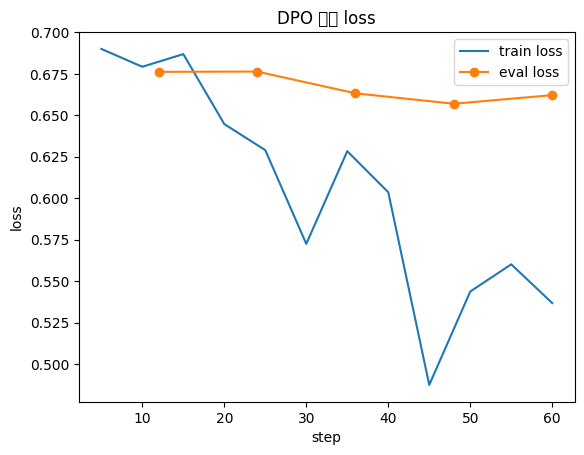

In [13]:
log = pd.DataFrame(trainer.state.log_history)
display(log.tail())

train_log = log[log["loss"].notna()] if "loss" in log else pd.DataFrame()
eval_log = log[log["eval_loss"].notna()] if "eval_loss" in log else pd.DataFrame()

if not train_log.empty:
    plt.figure()
    plt.plot(train_log["step"], train_log["loss"], label="train loss")
    if not eval_log.empty:
        plt.plot(eval_log["step"], eval_log["eval_loss"], label="eval loss", marker="o")
    plt.xlabel("step")
    plt.ylabel("loss")
    plt.title("DPO 학습 loss")
    plt.legend()
    plt.show()

## 8. DPO 모델과 기본 GPT-2 생성 비교

저장한 결과는 LoRA adapter이므로 `AutoPeftModelForCausalLM`로 불러온다. 기본 GPT-2도 함께 불러와 같은 prompt에 대한 출력을 비교한다.

In [14]:
dpo_model = AutoPeftModelForCausalLM.from_pretrained(DPO_DIR).to(device)
dpo_model.eval()

gpt2_model = AutoModelForCausalLM.from_pretrained(MODEL_NAME).to(device)
gpt2_model.config.pad_token_id = tokenizer.pad_token_id
gpt2_model.eval()

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-11): 12 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=2304, nx=768)
          (c_proj): Conv1D(nf=768, nx=768)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=3072, nx=768)
          (c_proj): Conv1D(nf=768, nx=3072)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=50257, bias=False)
)

### 8.1 생성 설정

In [15]:
generation_config = GenerationConfig(
    do_sample=True,
    top_k=20,
    top_p=0.9,
    temperature=0.8,
    max_new_tokens=80,
    pad_token_id=tokenizer.pad_token_id,
    eos_token_id=tokenizer.eos_token_id,
)

@torch.inference_mode()
def generate_response(model, prompt):
    inputs = tokenizer(prompt, return_tensors="pt").to(device)
    output = model.generate(**inputs, generation_config=generation_config)
    return tokenizer.decode(output[0], skip_special_tokens=True)

### 8.2 같은 prompt로 결과 비교

In [16]:
PROMPT = "Explain why building a daily drawing habit can be difficult and give practical advice."

print("[기본 GPT-2]")
print(generate_response(gpt2_model, PROMPT))
print("\n[DPO 모델]")
print(generate_response(dpo_model, PROMPT))

[기본 GPT-2]
Explain why building a daily drawing habit can be difficult and give practical advice.

Learn about how to create a daily drawing habit.

How to create a daily drawing habit.

How to create a daily drawing habit.

How to create a daily drawing habit.

How to create a daily drawing habit.

How to create a daily drawing habit.

How to create a daily drawing habit.

How to create a daily drawing

[DPO 모델]
Explain why building a daily drawing habit can be difficult and give practical advice.

How to Find a Job?

If you're looking for a job, you may have noticed that some people are more willing to work in the field than others.

This is because they are less likely to be self-employed, and they have less time to devote to their own personal needs.

If you're looking for a job in the field of graphic design,


## 9. DPO 핵심 정리

1. DPO는 `prompt`, `chosen`, `rejected` preference pair를 직접 학습한다.
2. 별도의 reward model을 먼저 학습하고 PPO를 수행하는 전통적인 RLHF 파이프라인보다 구현이 단순하다.
3. policy의 chosen/rejected log-probability 차이를 reference policy와 비교해 선호 방향으로 policy를 이동시킨다.
4. `beta`는 reference model과의 상대적인 변화 크기를 조절하는 중요한 하이퍼파라미터다.
5. LoRA를 함께 사용하면 전체 GPT-2 파라미터를 업데이트하지 않고도 preference fine-tuning을 수행할 수 있다.